# Leave-KGC-Models-Out: Fully Automated Evaluation Loop  — RELATION PREDICTION
**REVISED v2 - With All 3 Changes Implemented**

## KEY REVISIONS:
1. **Consistency & Generalizability**: Normalized using `value/max` formula (max=1, min≠0)
2. **Aggregated Changes**: Final summed changes normalized column-wise (max per column = 1)
3. **Multiple Plots**: 7 different visualization styles (bar, box, std bar, violin, heatmap, combined)

No-Free-Lunch Principle in Metric Aggregation for Knowledge Graph Completion

## Step 0A: Mount Google Drive & Install Dependencies

In [1]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
##################################################################################
import shutil

source = '/content/drive/MyDrive/Relation_pred_main_file.csv'
target = '/content/Relation_pred_main_file.csv'

shutil.copy(source, target)
print("File copied to /content/")



File copied to /content/


## Step 1: Load Original Dataset

In [4]:
import pandas as pd
import numpy as np
import os
import itertools
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

ORIGINAL_DATA_PATH = '/content/drive/MyDrive/Relation_pred_main_file.csv'
DATA_DIR = os.path.dirname(ORIGINAL_DATA_PATH)
RESULTS_OUTPUT_DIR = os.path.join(DATA_DIR, 'No_Free_Lunch_Results_Relation')
os.makedirs(RESULTS_OUTPUT_DIR, exist_ok=True)

def load_file(path):
    """Load CSV with multiple fallback separators."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    for sep in [',', '\t', ' ']:
        try:
            return pd.read_csv(path, sep=sep)
        except Exception:
            continue
    raise ValueError(f"Could not parse {path} as CSV.")

FULL_DF = load_file(ORIGINAL_DATA_PATH)
ALL_MODELS = sorted(FULL_DF['Models'].unique().tolist())
ALL_PAIRS = list(itertools.combinations(ALL_MODELS, 2))

print(f"✓ Dataset loaded: {FULL_DF.shape[0]} rows × {FULL_DF.shape[1]} columns")
print(f"✓ Unique KGC models detected ({len(ALL_MODELS)}):")
for m in ALL_MODELS:
    print(f"   • {m}")
print(f"\n✓ Total model pairs to evaluate: {len(ALL_PAIRS)}")
print(f"✓ Results will be saved to: {RESULTS_OUTPUT_DIR}/")

✓ Dataset loaded: 12 rows × 19 columns
✓ Unique KGC models detected (12):
   • ComplEx
   • Con
   • DRUM
   • DistMult
   • FMS
   • Path
   • PathCon
   • QuatE
   • R-GCN
   • RotatE
   • SimplE
   • TransE

✓ Total model pairs to evaluate: 66
✓ Results will be saved to: /content/drive/MyDrive/No_Free_Lunch_Results_Relation/


In [5]:
FULL_DF

,Models,MRR_d0,H@1_d0,H@3_d0,MRR_d1,H@1_d1,H@3_d1,MRR_d2,H@1_d2,H@3_d2,MRR_d3,H@1_d3,H@3_d3,MRR_d4,H@1_d4,H@3_d4,MRR_d5,H@1_d5,H@3_d5
0,TransE,96.2,94.0,98.2,96.6,94.6,98.4,97.1,95.5,98.4,78.4,66.9,87.0,84.1,78.1,88.9,96.6,94.8,98.0
1,ComplEx,90.1,84.4,95.2,92.4,87.9,97.0,98.5,97.9,99.1,84.0,77.7,88.0,70.3,62.5,76.5,95.3,93.1,96.8
2,DistMult,66.1,43.9,86.8,87.5,80.6,93.6,78.6,58.4,98.7,84.7,78.7,89.1,63.4,52.4,72.0,92.7,88.6,96.1
3,RotatE,97.9,96.7,98.6,97.0,95.1,98.0,98.4,97.9,98.6,79.9,73.5,82.3,72.9,69.1,75.6,95.3,93.4,96.4
4,SimplE,98.3,97.2,99.1,97.1,95.5,98.7,97.2,96.4,97.6,73.0,65.9,75.5,71.6,67.1,74.8,92.4,89.2,94.8
5,QuatE,98.3,97.2,99.1,97.4,95.8,98.8,98.1,97.5,98.3,82.3,76.7,85.2,75.2,70.6,78.3,94.6,92.2,96.2
6,DRUM,94.5,94.5,97.8,95.9,90.5,95.8,96.9,95.6,98.0,85.4,77.8,91.2,71.5,64.0,74.0,95.8,93.0,98.7
7,R-GCN,69.6,60.1,76.0,93.1,90.3,94.2,90.9,82.4,97.9,82.2,75.0,84.8,78.5,71.2,82.6,96.2,93.8,97.9
8,Path,93.7,91.8,95.1,97.2,95.7,98.6,98.1,97.1,98.9,93.3,89.7,96.1,73.7,68.5,76.4,96.9,94.8,99.1
9,Con,96.2,93.4,98.8,97.8,96.1,99.5,96.0,92.7,99.2,94.3,89.4,99.3,87.5,81.5,92.8,97.7,96.1,99.4


## Step 2A: Core MCDM Functions

In [6]:
from scipy.stats import zscore, kendalltau, pearsonr, spearmanr
from scipy import stats

'''

def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """Min-max normalize: beneficial → [0,1], non-beneficial → [0.6, 0.8]."""
    df_norm = df.copy()
    for col in beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = 1.0 if cmax == cmin else (df_norm[col] - cmin) / (cmax - cmin)
    for col in non_beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmax = df_norm[col].max()
        df_norm[col] = 0.6 if cmax == 0 else 0.6 + (df_norm[col] / cmax) * 0.2
    return df_norm
'''


def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """Min-max normalize with protection against zero variance (common with BERT/GNN models)."""
    df_norm = df.copy()

    for col in beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmin = df_norm[col].min()
        cmax = df_norm[col].max()
        if cmax == cmin:                    # All values are the same
            df_norm[col] = 1.0
        else:
            df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin)

    for col in non_beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmax = df_norm[col].max()
        if cmax == 0:
            df_norm[col] = 0.6
        else:
            df_norm[col] = 0.6 + (df_norm[col] / cmax) * 0.2

    return df_norm





def borda_count_local(df):
    m = df.shape[0]
    return (m - df.rank(ascending=False, method='average') + 1).sum(axis=1).round(4)

def zscore_average_local(df):
    return df.apply(zscore, axis=0, nan_policy='omit').fillna(0).mean(axis=1).round(4)

def topsis_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.array(weights) / np.sum(weights)
    norm = np.sqrt(np.sum(X**2, axis=0)); norm[norm == 0] = 1.0
    V = (X / norm) * w
    d_best = np.sqrt(np.sum((V - V.max(axis=0))**2, axis=1))
    d_worst = np.sqrt(np.sum((V - V.min(axis=0))**2, axis=1))
    return pd.Series(d_worst / (d_best + d_worst + 1e-12), index=df.index).round(4)

def vikor_local(df, weights=None, v=0.5):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.asarray(weights) / np.sum(weights)
    f_star, f_minus = X.max(axis=0), X.min(axis=0)
    denom = f_star - f_minus; denom[denom == 0] = 1.0
    D = (f_star - X) / denom
    S, R = np.dot(D, w), np.max(w * D, axis=1)
    S_min, S_max = S.min(), S.max()
    R_min, R_max = R.min(), R.max()
    S_denom = max(S_max - S_min, 1e-12)
    R_denom = max(R_max - R_min, 1e-12)
    Q = v * (S - S_min) / S_denom + (1 - v) * (R - R_min) / R_denom
    return pd.Series(Q, index=df.index).round(4)

def edas_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    av = X.mean(axis=0)
    PDA = np.sum((X >= av).astype(float) * ((X - av) / (av + 1e-12)) * w, axis=1)
    NDA = np.sum((X < av).astype(float) * ((av - X) / (av + 1e-12)) * w, axis=1)
    return pd.Series((PDA + NDA) / 2, index=df.index).round(4)

def moora_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    return pd.Series(((X / sq_sum) * w).sum(axis=1), index=df.index).round(4)

def waspas_local(df, weights=None, lam=0.5):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    X_norm = X / sq_sum
    WSM = (X_norm * w).sum(axis=1)
    prod = np.prod(X_norm ** w, axis=1)
    return pd.Series(lam * WSM + (1 - lam) * prod, index=df.index).round(4)

print("✓ MCDM functions defined")

✓ MCDM functions defined


## Step 2B: Evaluation Pipeline - With REVISED Consistency & Generalizability

In [7]:
from scipy.stats import zscore, kendalltau, pearsonr, spearmanr
from scipy import stats

MCDM_KEYS = ['Borda', 'ZMean', 'TOPSIS', 'VIKOR', 'EDAS', 'MOORA', 'WASPAS']


# ════════════════════════════════════════════════════════════════════
#  DATA-DRIVEN METRIC PARSING  (works for ANY metric set / suffix set)
#  Relation-prediction file has: MRR, H@1, H@3  with suffixes _d0.._d5
#  (No MR, no H@10 — so detection is automatic instead of hard-coded.)
# ════════════════════════════════════════════════════════════════════

# Lower MR = better → non-beneficial. Everything else (MRR, H@k) higher = better.
NON_BENEFICIAL_PREFIXES = ('MR',)   # plain MR only (MRR handled separately below)

def _metric_family(col):
    """Return the metric-family prefix of a column, e.g. 'MRR_d3' -> 'MRR'.
    Family = everything before the LAST underscore."""
    return col.rsplit('_', 1)[0] if '_' in col else col

def _dataset_suffix(col):
    """Return the dataset suffix of a column, e.g. 'MRR_d3' -> 'd3'."""
    return col.rsplit('_', 1)[1] if '_' in col else col

def get_metric_families(columns):
    """Map family-name -> list of columns, preserving first-seen order."""
    fams = {}
    for col in columns:
        fam = _metric_family(col)
        fams.setdefault(fam, []).append(col)
    return fams

def get_datasets(columns):
    """Ordered list of unique dataset suffixes."""
    seen = []
    for col in columns:
        ds = _dataset_suffix(col)
        if ds not in seen:
            seen.append(ds)
    return seen

def is_non_beneficial(family):
    """MR (mean rank) is non-beneficial; MRR and all Hits@k are beneficial."""
    return family == 'MR'

def split_beneficial(columns):
    """Split a column list into (beneficial, non_beneficial) by family."""
    b, nb = [], []
    for col in columns:
        fam = _metric_family(col)
        (nb if is_non_beneficial(fam) else b).append(col)
    return b, nb



def normalize_for_mcdm(df, beneficial_cols, non_beneficial_cols):
    """Min-max normalize with protection against zero variance (common with BERT/GNN models)."""
    df_norm = df.copy()

    for col in beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmin = df_norm[col].min()
        cmax = df_norm[col].max()
        if cmax == cmin:                    # All values are the same
            df_norm[col] = 1.0
        else:
            df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin)

    for col in non_beneficial_cols:
        if col not in df_norm.columns:
            continue
        cmax = df_norm[col].max()
        if cmax == 0:
            df_norm[col] = 0.6
        else:
            df_norm[col] = 0.6 + (df_norm[col] / cmax) * 0.2

    return df_norm


def borda_count_local(df):
    m = df.shape[0]
    return (m - df.rank(ascending=False, method='average') + 1).sum(axis=1).round(4)

def zscore_average_local(df):
    return df.apply(zscore, axis=0, nan_policy='omit').fillna(0).mean(axis=1).round(4)

def topsis_local(df, weights=None):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.array(weights) / np.sum(weights)
    norm = np.sqrt(np.sum(X**2, axis=0)); norm[norm == 0] = 1.0
    V = (X / norm) * w
    d_best = np.sqrt(np.sum((V - V.max(axis=0))**2, axis=1))
    d_worst = np.sqrt(np.sum((V - V.min(axis=0))**2, axis=1))
    return pd.Series(d_worst / (d_best + d_worst + 1e-12), index=df.index).round(4)

def vikor_local(df, weights=None, v=0.5):
    X = df.values.astype(float)
    m, n = X.shape
    w = np.ones(n) / n if weights is None else np.asarray(weights) / np.sum(weights)
    f_star, f_minus = X.max(axis=0), X.min(axis=0)
    denom = f_star - f_minus; denom[denom == 0] = 1.0
    D = (f_star - X) / denom
    S, R = np.dot(D, w), np.max(w * D, axis=1)
    S_min, S_max = S.min(), S.max()
    R_min, R_max = R.min(), R.max()
    S_denom = max(S_max - S_min, 1e-12)
    R_denom = max(R_max - R_min, 1e-12)
    Q = v * (S - S_min) / S_denom + (1 - v) * (R - R_min) / R_denom
    return pd.Series(Q, index=df.index).round(4)

def edas_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    av = X.mean(axis=0)
    PDA = np.sum((X >= av).astype(float) * ((X - av) / (av + 1e-12)) * w, axis=1)
    NDA = np.sum((X < av).astype(float) * ((av - X) / (av + 1e-12)) * w, axis=1)
    return pd.Series((PDA + NDA) / 2, index=df.index).round(4)

def moora_local(df, weights=None):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    return pd.Series(((X / sq_sum) * w).sum(axis=1), index=df.index).round(4)

def waspas_local(df, weights=None, lam=0.5):
    X = df.values.astype(float)
    w = np.ones(X.shape[1]) / X.shape[1] if weights is None else np.asarray(weights) / np.sum(weights)
    sq_sum = np.sqrt((X**2).sum(axis=0)); sq_sum[sq_sum == 0] = 1.0
    X_norm = X / sq_sum
    WSM = (X_norm * w).sum(axis=1)
    prod = np.prod(X_norm ** w, axis=1)
    return pd.Series(lam * WSM + (1 - lam) * prod, index=df.index).round(4)


def _run_mcdm(df_filtered):
    """Robust MCDM that safely handles NaN/inf caused by mixed-scale models."""
    r = pd.DataFrame(index=df_filtered.index)

    r['Borda'] = borda_count_local(df_filtered)
    r['ZMean'] = zscore_average_local(df_filtered)
    r['TOPSIS'] = topsis_local(df_filtered)
    r['VIKOR'] = vikor_local(df_filtered)
    r['EDAS'] = edas_local(df_filtered)
    r['MOORA'] = moora_local(df_filtered)
    r['WASPAS'] = waspas_local(df_filtered)

    for col in MCDM_KEYS:
        asc = col == 'VIKOR'
        ranked = r[col].rank(ascending=asc, method='min')
        max_rank = len(df_filtered) + 1
        r[f'{col}_R'] = ranked.fillna(max_rank).astype(int)

    return r


# ── Consistency with value/max normalization (data-driven families) ──
def _run_consistency(df_metrics, df_normalized):
    """Returns Consistency with value/max normalization (max=1, min!=0).
    Builds one consensus 'Mean_<family>' metric per metric family present in the data,
    so it works for relation prediction (MRR, H@1, H@3) just as for tail prediction."""
    families = get_metric_families(df_metrics.columns)

    b_cols, nb_cols = split_beneficial(df_metrics.columns)
    df_norm = normalize_for_mcdm(df_metrics, b_cols, nb_cols)

    results = pd.DataFrame(index=df_metrics.index)
    results['EDAS_AS'] = edas_local(df_norm)
    results['TOPSIS'] = topsis_local(df_norm)
    results['VIKOR_Q'] = vikor_local(df_norm)
    results['Borda_Score'] = borda_count_local(df_norm)
    results['Z_Mean'] = zscore_average_local(df_norm)
    results['MOORA'] = moora_local(df_norm)
    results['WASPAS'] = waspas_local(df_norm)

    # One consensus metric per family. MR inverted (lower better → negate).
    consensus_metrics = {}
    for fam, cols in families.items():
        mean_series = df_metrics[cols].mean(axis=1)
        if is_non_beneficial(fam):
            mean_series = -mean_series          # invert so higher = better
            label = f'Mean_{fam}_inverted'
        else:
            label = f'Mean_{fam}'
        results[label] = mean_series
        consensus_metrics[f'Mean_{fam}'] = label

    mcdm_score_columns = {
        'EDAS': 'EDAS_AS', 'TOPSIS': 'TOPSIS', 'VIKOR': 'VIKOR_Q',
        'Borda': 'Borda_Score', 'Z-Score': 'Z_Mean', 'MOORA': 'MOORA', 'WASPAS': 'WASPAS'
    }

    all_corr = []
    for mn, mc in consensus_metrics.items():
        metric_data = results[mc]
        for mname, scol in mcdm_score_columns.items():
            md = -results[scol] if mname == 'VIKOR' else results[scol].copy()
            try:
                tau, _ = kendalltau(md, metric_data)
                r, _ = pearsonr(md, metric_data)
                rho, _ = spearmanr(md, metric_data)
            except Exception:
                tau = r = rho = np.nan
            all_corr.append({'Method': mname, 'Kendall_t': tau, 'Pearson_r': r, 'Spearman_rho': rho})

    summary = pd.DataFrame(all_corr)
    overall = []
    for method in mcdm_score_columns.keys():
        md = summary[summary['Method'] == method]
        mk = md['Kendall_t'].mean()
        mp = md['Pearson_r'].mean()
        ms = md['Spearman_rho'].mean()
        overall.append({'Method': method, 'Overall_Mean_Correlation': (mk + mp + ms) / 3})

    result_df = pd.DataFrame(overall)
    max_val = result_df['Overall_Mean_Correlation'].max()
    if max_val > 0:
        result_df['Overall_Mean_Correlation'] = (result_df['Overall_Mean_Correlation'] / max_val).round(4)
    return result_df


def _run_stability(df_metrics):
    """Returns normalized stability score per method (higher = more stable).
    Metric families are detected from the data (relation: MRR, H@1, H@3)."""
    datasets = get_datasets(df_metrics.columns)

    dataset_columns = {}
    for ds in datasets:
        dataset_columns[ds] = [c for c in df_metrics.columns if _dataset_suffix(c) == ds]

    # Detect metric families present in the data (instead of a hard-coded list)
    metric_types = list(get_metric_families(df_metrics.columns).keys())
    name_map = {'VQ': 'VIKOR Q', 'BS': 'Borda', 'ZS': 'Z-Score', 'WA': 'WASPAS', 'MO': 'MOORA', 'ED': 'EDAS', 'TP': 'TOPSIS'}

    all_ranks = {}
    for metric_type in metric_types:
        mc_by_ds = {}
        for ds in datasets:
            mc = [c for c in dataset_columns[ds] if _metric_family(c) == metric_type]
            if mc:
                mc_by_ds[ds] = mc
        if not mc_by_ds:
            continue
        ds_ranks = {}
        for ds, metric_cols in mc_by_ds.items():
            df_m = df_metrics[metric_cols].copy()
            if is_non_beneficial(metric_type):
                b, nb = [], metric_cols
            else:
                b, nb = metric_cols, []
            df_n = normalize_for_mcdm(df_m, b, nb)
            res_ds = pd.DataFrame(index=df_metrics.index)
            res_ds['ED_Rank'] = edas_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['TP_Rank'] = topsis_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['VQ_Rank'] = vikor_local(df_n).rank(ascending=True, method='min').astype(int)
            res_ds['BS_Rank'] = borda_count_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['ZS_Rank'] = zscore_average_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['MO_Rank'] = moora_local(df_n).rank(ascending=False, method='min').astype(int)
            res_ds['WA_Rank'] = waspas_local(df_n).rank(ascending=False, method='min').astype(int)
            ds_ranks[ds] = res_ds[['ED_Rank', 'TP_Rank', 'VQ_Rank', 'BS_Rank', 'ZS_Rank', 'MO_Rank', 'WA_Rank']].copy()
        all_ranks[metric_type] = ds_ranks

    overall_var = pd.DataFrame(index=df_metrics.index)
    for short, full in name_map.items():
        all_mv = []
        for mt, ds_ranks in all_ranks.items():
            for ds, rdf in ds_ranks.items():
                col = f'{short}_Rank'
                if col in rdf.columns:
                    all_mv.append(rdf[col])
        if all_mv:
            stacked = pd.concat(all_mv, axis=1)
            overall_var[full] = stacked.var(axis=1, ddof=0).round(3)

    if overall_var.empty:
        return {m: 0.5 for m in ['Borda', 'Z-Score', 'TOPSIS', 'VIKOR', 'EDAS', 'MOORA', 'WASPAS']}

    raw_mean = overall_var.mean()
    inv = 1 / raw_mean.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {k: 0.0 for k in raw_mean.index}
    else:
        norm_series = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_series.to_dict()

    mapping = {'VIKOR Q': 'VIKOR', 'Z-Score': 'Z-Score', 'Borda': 'Borda', 'WASPAS': 'WASPAS', 'MOORA': 'MOORA', 'EDAS': 'EDAS', 'TOPSIS': 'TOPSIS'}
    return {mapping.get(k, k): v for k, v in norm.items()}


def _run_independency(df_metrics):
    """Leave-one-metric-family-out robustness (families detected from data)."""
    metric_families = get_metric_families(df_metrics.columns)
    all_cols = df_metrics.columns.tolist()

    baseline = _run_mcdm(df_metrics)
    def avg_delta(base, new_res):
        return {m: (base[f'{m}_R'] - new_res[f'{m}_R']).abs().mean() for m in MCDM_KEYS}

    robustness_scores = {m: 0.0 for m in MCDM_KEYS}
    for fam, excl in metric_families.items():
        remaining = [c for c in all_cols if c not in excl]
        if not remaining:
            continue
        new_res = _run_mcdm(df_metrics[remaining])
        for m, delta in avg_delta(baseline, new_res).items():
            robustness_scores[m] += delta
    for m in robustness_scores:
        robustness_scores[m] /= max(len(metric_families), 1)

    raw = pd.Series(robustness_scores)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    mapping = {'ZMean': 'Z-Score'}
    return {mapping.get(k, k): v for k, v in norm.items()}


def _run_robustness(df_metrics, n_iter=1000):
    """Noise injection robustness."""
    baseline = _run_mcdm(df_metrics)
    noise_levels = [0.05, 0.10, 0.15, 0.20]
    agg_deltas = {m: 0.0 for m in MCDM_KEYS}

    for noise in noise_levels:
        noise_deltas = {m: 0.0 for m in MCDM_KEYS}
        for _ in range(n_iter):
            df_noisy = df_metrics.copy()
            for col in df_noisy.columns:
                std = df_noisy[col].std()
                df_noisy[col] += np.random.normal(0, noise * std, size=len(df_noisy))
            new_res = _run_mcdm(df_noisy)
            for m in MCDM_KEYS:
                noise_deltas[m] += (baseline[f'{m}_R'] - new_res[f'{m}_R']).abs().mean()
        for m in MCDM_KEYS:
            agg_deltas[m] += noise_deltas[m] / n_iter

    for m in MCDM_KEYS:
        agg_deltas[m] /= len(noise_levels)

    raw = pd.Series(agg_deltas)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    mapping = {'ZMean': 'Z-Score'}
    return {mapping.get(k, k): v for k, v in norm.items()}


# ── Generalizability with value/max normalization (leave-dataset-out) ──
def _run_generalizability(df_metrics):
    """Leave-dataset-out generalizability with value/max normalization (max=1, min!=0)."""
    datasets = get_datasets(df_metrics.columns)

    baseline = _run_mcdm(df_metrics)
    agg_deltas = {m: 0.0 for m in MCDM_KEYS}

    for ds in datasets:
        keep_cols = [c for c in df_metrics.columns if _dataset_suffix(c) != ds]
        if not keep_cols:
            continue
        new_res = _run_mcdm(df_metrics[keep_cols])
        for m in MCDM_KEYS:
            agg_deltas[m] += (baseline[f'{m}_R'] - new_res[f'{m}_R']).abs().mean()

    for m in MCDM_KEYS:
        agg_deltas[m] /= max(len(datasets), 1)

    raw = pd.Series(agg_deltas)
    inv = 1 / raw.replace(0, np.inf)
    max_inv = inv.max()
    if max_inv == 0 or np.isinf(max_inv):
        norm = {m: 0.0 for m in MCDM_KEYS}
    else:
        norm_s = (inv / max_inv).replace([np.inf, -np.inf], 0).fillna(0).round(4)
        norm = norm_s.to_dict()

    result_df = pd.DataFrame(list(norm.items()), columns=['Method', 'Generalizability'])
    max_val = result_df['Generalizability'].max()
    if max_val > 0:
        result_df['Generalizability'] = (result_df['Generalizability'] / max_val).round(4)

    mapping = {'ZMean': 'Z-Score'}
    result_df['Method'] = result_df['Method'].map(mapping).fillna(result_df['Method'])
    return result_df


def run_full_pipeline(df, n_robustness_iter=1000):
    """Complete evaluation pipeline."""
    df_metrics = df.drop(columns=['Models']).copy()
    df_metrics.index = df['Models']

    b_cols, nb_cols = split_beneficial(df_metrics.columns)
    df_norm = normalize_for_mcdm(df_metrics, b_cols, nb_cols)

    df_cons = _run_consistency(df_metrics, df_norm)
    df_cons = df_cons.rename(columns={'Overall_Mean_Correlation': 'Consistency'})

    stab_dict = _run_stability(df_metrics)
    df_stab = pd.DataFrame(list(stab_dict.items()), columns=['Method', 'Stability'])

    ind_dict = _run_independency(df_metrics)
    df_ind = pd.DataFrame(list(ind_dict.items()), columns=['Method', 'Independency'])

    rob_dict = _run_robustness(df_metrics, n_iter=n_robustness_iter)
    df_rob = pd.DataFrame(list(rob_dict.items()), columns=['Method', 'Robustness'])

    df_gen = _run_generalizability(df_metrics)

    summary = df_cons.merge(df_stab, on='Method').merge(df_ind, on='Method').merge(df_rob, on='Method').merge(df_gen, on='Method')
    summary['Overall Score'] = summary[['Consistency', 'Stability', 'Independency', 'Robustness', 'Generalizability']].mean(axis=1).round(4)
    summary = summary.sort_values(by='Overall Score', ascending=False).reset_index(drop=True)
    return summary

print("Full evaluation pipeline defined (RELATION PREDICTION - data-driven metric parsing)")


Full evaluation pipeline defined (RELATION PREDICTION - data-driven metric parsing)


## Step 3: Setup Constants and Directories

In [8]:
BASE_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Base_Results')
ONE_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'One_KGC_Removal')
TWO_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Two_KGC_Removal')
GROUP_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Group_KGC_Removal')
PLOT_DIR = os.path.join(RESULTS_OUTPUT_DIR, 'Plots')

for d in [BASE_DIR, ONE_DIR, TWO_DIR, GROUP_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

METRIC_COLS = ['Consistency', 'Stability', 'Independency', 'Robustness', 'Generalizability']
MCDM_ORDER = ['Z-Score', 'Borda', 'MOORA', 'EDAS', 'TOPSIS', 'WASPAS', 'VIKOR']
N_ROBUSTNESS_ITER = 100

# ===================================================================
# Updated KGC Groups - Matching the LaTeX table structure exactly
# ===================================================================
# ===================================================================
# Relation-Prediction model families
# Only models actually present in Relation_pred_main_file are kept;
# any group member not in the data is ignored automatically downstream.
# ===================================================================
KGC_GROUPS = {
    'Translational / Geometric Models': [
        'TransE', 'RotatE'
    ],

    'Semantic Matching Models': [
        'DistMult', 'ComplEx', 'SimplE', 'QuatE'
    ],

    'GNN-based Models': [
        'R-GCN'
    ],

    'Path / Relation-Context Models': [
        'DRUM', 'Path', 'Con', 'PathCon', 'FMS'
    ]
}

# Keep only group members that actually exist in the loaded data,
# and drop any group that ends up empty (robust to data changes).
KGC_GROUPS = {
    g: [m for m in members if m in ALL_MODELS]
    for g, members in KGC_GROUPS.items()
}
KGC_GROUPS = {g: members for g, members in KGC_GROUPS.items() if members}

def scores_to_ranks(score_df):
    """Convert scores to ranks (higher score = better rank)."""
    rank_df = score_df.copy().astype(float)
    for col in score_df.columns:
        rank_df[col] = score_df[col].rank(ascending=False, method='min').astype(int)
    return rank_df


print(f"✓ Setup complete - Output directory: {RESULTS_OUTPUT_DIR}")
print(f"✓ KGC Groups defined ({len(KGC_GROUPS)} groups):")
for group_name, models in KGC_GROUPS.items():
    print(f"   • {group_name}: {len(models)} models")

✓ Setup complete - Output directory: /content/drive/MyDrive/No_Free_Lunch_Results_Relation
✓ KGC Groups defined (4 groups):
   • Translational / Geometric Models: 2 models
   • Semantic Matching Models: 4 models
   • GNN-based Models: 1 models
   • Path / Relation-Context Models: 5 models


## Step 4: Compute Baseline

In [9]:
base_scores_path = os.path.join(BASE_DIR, 'base_scores.csv')
base_ranks_path = os.path.join(BASE_DIR, 'base_ranks.csv')

if os.path.exists(base_scores_path):
    base_scores = pd.read_csv(base_scores_path, index_col=0)
    base_ranks = pd.read_csv(base_ranks_path, index_col=0)
    print('Loaded cached baseline scores.')
else:
    print('Computing baseline...')
    t0 = time.time()
    base_summary = run_full_pipeline(FULL_DF, n_robustness_iter=N_ROBUSTNESS_ITER)
    print(f'  Completed in {time.time() - t0:.1f}s')
    base_scores = base_summary.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
    base_ranks = scores_to_ranks(base_scores)
    base_summary.to_csv(os.path.join(BASE_DIR, 'base_summary.csv'))
    base_scores.to_csv(base_scores_path)
    base_ranks.to_csv(base_ranks_path)

print('\nBaseline Scores:')
print(base_scores)
print('\nBaseline Ranks:')
print(base_ranks)

Computing baseline...
  Completed in 10.4s

Baseline Scores:
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       1.0000     1.0000        1.0000      1.0000            1.0000
Borda         0.9777     1.0000        0.2857      0.1360            0.3529
MOORA         0.9816     1.0000        0.2500      0.4298            0.5000
EDAS          0.1801     0.6927        0.1000      0.0717            0.1791
TOPSIS        0.9739     1.0000        0.2500      0.2570            0.5000
WASPAS        0.9764     1.0000        0.2500      0.4756            0.5217
VIKOR         0.9578     1.0000        0.1667      0.1235            0.3750

Baseline Ranks:
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score            1          1             1           1                 1
Borda     

## Step 5: One-KGC-Out Analysis

In [10]:
RAW_ONE_DIR = os.path.join(ONE_DIR, 'raw')
os.makedirs(RAW_ONE_DIR, exist_ok=True)

print('=' * 70)
print('ONE-KGC-OUT ANALYSIS')
print(f'Total models: {len(ALL_MODELS)}')
print('=' * 70)

t0_loop = time.time()
one_abs_score_changes = []
one_abs_rank_changes = []

for m in ALL_MODELS:
    score_out = os.path.join(RAW_ONE_DIR, f'scores_without_{m}.csv')
    rank_out = os.path.join(RAW_ONE_DIR, f'ranks_without_{m}.csv')

    if os.path.exists(score_out) and os.path.exists(rank_out):
        res_scores = pd.read_csv(score_out, index_col=0)
        res_ranks = pd.read_csv(rank_out, index_col=0)
        print(f'  Loaded: {m}')
    else:
        t1 = time.time()
        print(f'  Removing: {m}', end=' ... ')
        fdf = FULL_DF[FULL_DF['Models'] != m].copy().reset_index(drop=True)
        res = run_full_pipeline(fdf, n_robustness_iter=N_ROBUSTNESS_ITER)
        res_scores = res.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
        res_ranks = scores_to_ranks(res_scores)
        res_scores.to_csv(score_out)
        res_ranks.to_csv(rank_out)
        print(f'OK ({time.time()-t1:.1f}s)')

    abs_diff_scores = (res_scores - base_scores).abs()
    abs_diff_ranks = (res_ranks - base_ranks).abs()
    one_abs_score_changes.append(abs_diff_scores)
    one_abs_rank_changes.append(abs_diff_ranks)

one_sum_abs_scores = sum(one_abs_score_changes)
one_sum_abs_ranks = sum(one_abs_rank_changes)

one_sum_abs_scores.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes.csv'))
one_sum_abs_ranks.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes.csv'))

print('\nONE-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES')
print(one_sum_abs_scores.to_string())
print(f'\n✓ Completed in {(time.time()-t0_loop)/60:.1f} min')

ONE-KGC-OUT ANALYSIS
Total models: 12
  Removing: ComplEx ... OK (10.1s)
  Removing: Con ... OK (10.8s)
  Removing: DRUM ... OK (10.9s)
  Removing: DistMult ... OK (9.2s)
  Removing: FMS ... OK (10.8s)
  Removing: Path ... OK (10.8s)
  Removing: PathCon ... OK (9.7s)
  Removing: QuatE ... OK (10.5s)
  Removing: R-GCN ... OK (10.7s)
  Removing: RotatE ... OK (10.0s)
  Removing: SimplE ... OK (9.8s)
  Removing: TransE ... OK (10.7s)

ONE-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.0000     0.0000        3.0000      0.1411            0.0625
Borda         0.0905     0.0000        2.2666      0.6716            1.3196
MOORA         0.0980     0.0000        2.3332      1.9715            1.3115
EDAS          0.8229     0.6754        1.8766      0.3164            0.9188
TOPSIS        0.1117     0.0000        3.0833      1.6890         

## Step 7: Group-KGC-Out Analysis

In [11]:
RAW_GRP_DIR = os.path.join(GROUP_DIR, 'raw')
os.makedirs(RAW_GRP_DIR, exist_ok=True)

print('=' * 70)
print('GROUP-KGC-OUT ANALYSIS')
print('=' * 70)

grp_abs_score_changes = []
grp_abs_rank_changes = []

for grp, members in KGC_GROUPS.items():
    # Create safe filename (remove spaces, slashes, etc.)
    safe_name = grp.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    score_out = os.path.join(RAW_GRP_DIR, f'scores_without_{safe_name}.csv')
    rank_out = os.path.join(RAW_GRP_DIR, f'ranks_without_{safe_name}.csv')

    if os.path.exists(score_out) and os.path.exists(rank_out):
        res_scores = pd.read_csv(score_out, index_col=0)
        res_ranks = pd.read_csv(rank_out, index_col=0)
        print(f'  Loaded: {grp}')
    else:
        print(f'  Removing group: {grp} ({len(members)} models: {members})')
        fdf = FULL_DF[~FULL_DF['Models'].isin(members)].copy().reset_index(drop=True)
        t0 = time.time()
        res = run_full_pipeline(fdf, n_robustness_iter=N_ROBUSTNESS_ITER)
        res_scores = res.set_index('Method')[METRIC_COLS].reindex(MCDM_ORDER).round(4)
        res_ranks = scores_to_ranks(res_scores)

        res_scores.to_csv(score_out)
        res_ranks.to_csv(rank_out)
        print(f'    ✓ Saved ({time.time()-t0:.1f}s)')

    abs_diff_scores = (res_scores - base_scores).abs()
    abs_diff_ranks = (res_ranks - base_ranks).abs()
    grp_abs_score_changes.append(abs_diff_scores)
    grp_abs_rank_changes.append(abs_diff_ranks)

grp_sum_abs_scores = sum(grp_abs_score_changes)
grp_sum_abs_ranks = sum(grp_abs_rank_changes)

grp_sum_abs_scores.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes.csv'))
grp_sum_abs_ranks.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes.csv'))

print('\nGROUP-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES')
print(grp_sum_abs_scores.to_string())
print(f'\n✓ Saved to {GROUP_DIR}/')

GROUP-KGC-OUT ANALYSIS
  Removing group: Translational / Geometric Models (2 models: ['TransE', 'RotatE'])
    ✓ Saved (10.6s)
  Removing group: Semantic Matching Models (4 models: ['DistMult', 'ComplEx', 'SimplE', 'QuatE'])
    ✓ Saved (9.2s)
  Removing group: GNN-based Models (1 models: ['R-GCN'])
    ✓ Saved (10.7s)
  Removing group: Path / Relation-Context Models (5 models: ['DRUM', 'Path', 'Con', 'PathCon', 'FMS'])
    ✓ Saved (10.7s)

GROUP-KGC-OUT SUM OF ABSOLUTE SCORE CHANGES
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.0000     0.1783        2.0000      0.0000            0.3333
Borda         0.0592     0.1783        1.6461      0.2807            0.5858
MOORA         0.0606     0.1783        2.0000      0.9334            0.6381
EDAS          1.1853     0.6800        1.4666      0.1620            0.3878
TOPSIS        0.0609     0.1783        2.0000      0.60

## Step 8: REVISED - Normalize Aggregated Changes (Column-wise: max=1, min≠0)

In [12]:
# REVISED: Normalize aggregated changes column-wise using value/max formula
def normalize_changes_column_wise(change_df):
    """Normalize changes column-wise using value/max formula.
    For each column (metric): value_normalized = value / max(column)
    Result: max in each column = 1, min > 0 (unless original was 0)
    """
    normalized_df = change_df.copy()
    for col in normalized_df.columns:
        col_max = normalized_df[col].max()
        if col_max > 0:
            normalized_df[col] = (normalized_df[col] / col_max).round(4)
    return normalized_df


print('=' * 70)
print('NORMALIZING AGGREGATED CHANGES (Column-wise: max=1, min≠0)')
print('=' * 70)

# Normalize - Only One-KGC-Out and Group-KGC-Out
one_norm = normalize_changes_column_wise(one_sum_abs_scores)
one_rank_norm = normalize_changes_column_wise(one_sum_abs_ranks)

grp_norm = normalize_changes_column_wise(grp_sum_abs_scores)
grp_rank_norm = normalize_changes_column_wise(grp_sum_abs_ranks)

# Save normalized versions
one_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes_NORMALIZED.csv'))
one_rank_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes_NORMALIZED.csv'))

grp_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes_NORMALIZED.csv'))
grp_rank_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes_NORMALIZED.csv'))

print('\nOne-KGC-Out (Normalized Score Changes):')
print(one_norm.to_string())

print('\nGroup-KGC-Out (Normalized Score Changes):')
print(grp_norm.to_string())

print('\n✓ Normalization complete')

NORMALIZING AGGREGATED CHANGES (Column-wise: max=1, min≠0)

One-KGC-Out (Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.0000        0.0        0.9730      0.0716            0.0354
Borda         0.1100        0.0        0.7351      0.3407            0.7464
MOORA         0.1191        0.0        0.7567      1.0000            0.7418
EDAS          1.0000        1.0        0.6086      0.1605            0.5197
TOPSIS        0.1357        0.0        1.0000      0.8567            0.7681
WASPAS        0.2012        0.0        0.7567      0.9927            0.6738
VIKOR         0.2264        0.0        0.6130      0.3079            1.0000

Group-KGC-Out (Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.0000 

In [13]:
# ══════════════════════════════════════════════════════════════════
# OVERALL FINAL AVERAGE SCORES — One-KGC vs Group-KGC (Separate)
# ══════════════════════════════════════════════════════════════════

print('=' * 70)
print('ONE-KGC REMOVAL — Average Scores (sorted highest → lowest)')
print('=' * 70)

# ── One-KGC: Per MCDM Method ──
one_per_method = one_norm.mean(axis=1).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
one_per_method['Rank'] = range(1, len(one_per_method) + 1)
print('\n Per MCDM Method:')
print(one_per_method.to_string())

# ── One-KGC: Per Evaluation Test ──
one_per_test = one_norm.mean(axis=0).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
one_per_test['Rank'] = range(1, len(one_per_test) + 1)
print('\n Per Evaluation Test:')
print(one_per_test.to_string())

# ── One-KGC: Grand Average ──
one_grand_avg = one_norm.values.mean().round(4)
print(f'\n One-KGC Grand Average Score: {one_grand_avg:.4f}')


print('\n' + '=' * 70)
print('GROUP-KGC REMOVAL — Average Scores (sorted highest → lowest)')
print('=' * 70)

# ── Group-KGC: Per MCDM Method ──
grp_per_method = grp_norm.mean(axis=1).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
grp_per_method['Rank'] = range(1, len(grp_per_method) + 1)
print('\n Per MCDM Method:')
print(grp_per_method.to_string())

# ── Group-KGC: Per Evaluation Test ──
grp_per_test = grp_norm.mean(axis=0).round(4).sort_values(ascending=False).to_frame(name='Avg Score')
grp_per_test['Rank'] = range(1, len(grp_per_test) + 1)
print('\n Per Evaluation Test:')
print(grp_per_test.to_string())

# ── Group-KGC: Grand Average ──
grp_grand_avg = grp_norm.values.mean().round(4)
print(f'\n Group-KGC Grand Average Score: {grp_grand_avg:.4f}')


print('\n' + '=' * 70)
print('COMPARISON SUMMARY')
print('=' * 70)
print(f'  One-KGC Grand Average   : {one_grand_avg:.4f}')
print(f'  Group-KGC Grand Average : {grp_grand_avg:.4f}')
print(f'  Difference (Group - One): {(grp_grand_avg - one_grand_avg):.4f}')
winner = 'Group-KGC' if grp_grand_avg > one_grand_avg else 'One-KGC'
print(f'  → {winner} removal has higher overall impact on MCDM methods')

ONE-KGC REMOVAL — Average Scores (sorted highest → lowest)

 Per MCDM Method:
         Avg Score  Rank
Method                  
EDAS        0.6578     1
TOPSIS      0.5521     2
WASPAS      0.5249     3
MOORA       0.5235     4
VIKOR       0.4295     5
Borda       0.3864     6
Z-Score     0.2160     7

 Per Evaluation Test:
                  Avg Score  Rank
Independency         0.7776     1
Generalizability     0.6407     2
Robustness           0.5329     3
Consistency          0.2561     4
Stability            0.1429     5

 One-KGC Grand Average Score: 0.4700

GROUP-KGC REMOVAL — Average Scores (sorted highest → lowest)

 Per MCDM Method:
         Avg Score  Rank
Method                  
EDAS        0.6726     1
WASPAS      0.6521     2
MOORA       0.5987     3
VIKOR       0.5306     4
TOPSIS      0.5028     5
Borda       0.4264     6
Z-Score     0.3312     7

 Per Evaluation Test:
                  Avg Score  Rank
Independency         0.9049     1
Generalizability     0.7419     2
R

### Step 8.1 Average of overall score, all reoval

In [14]:
# ══════════════════════════════════════════════════════════════════
# OVERALL SCORE PER REMOVAL — averaged across all removals
# Each removal → run_full_pipeline → Overall Score → then average
# ══════════════════════════════════════════════════════════════════

# ── ONE-KGC: load each saved result, get Overall Score, average ──
one_overall_scores = {}   # model_name → its Overall Score (per MCDM method)

for m in ALL_MODELS:
    score_path = os.path.join(RAW_ONE_DIR, f'scores_without_{m}.csv')
    res_scores = pd.read_csv(score_path, index_col=0)   # rows=MCDM, cols=METRIC_COLS
    res_scores['Overall Score'] = res_scores[METRIC_COLS].mean(axis=1).round(4)
    one_overall_scores[m] = res_scores['Overall Score']

# Build DataFrame: rows=MCDM methods, cols=each removed model
one_overall_df = pd.DataFrame(one_overall_scores, index=MCDM_ORDER)
print('Overall Score per MCDM method for each One-KGC removal:')
print(one_overall_df.round(4).to_string())

# Average across all model removals → one score per MCDM method
one_avg_overall = one_overall_df.mean(axis=1).round(4).sort_values(ascending=False)

print('\n' + '=' * 70)
print(f'ONE-KGC REMOVAL — Average Overall Score across {len(ALL_MODELS)} removals')
print('(Each model removed once → pipeline run → Overall Score → averaged)')
print('=' * 70)
one_result = one_avg_overall.to_frame(name='Avg Overall Score')
one_result['Rank'] = range(1, len(one_result) + 1)
print(one_result.to_string())
print(f'\n  One-KGC Grand Average: {one_avg_overall.mean():.4f}')


# ── GROUP-KGC: same approach ──
grp_overall_scores = {}   # group_name → its Overall Score (per MCDM method)

for grp, members in KGC_GROUPS.items():
    safe_name = grp.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    score_path = os.path.join(RAW_GRP_DIR, f'scores_without_{safe_name}.csv')
    res_scores = pd.read_csv(score_path, index_col=0)
    res_scores['Overall Score'] = res_scores[METRIC_COLS].mean(axis=1).round(4)
    grp_overall_scores[grp] = res_scores['Overall Score']

# Build DataFrame: rows=MCDM methods, cols=each removed group
grp_overall_df = pd.DataFrame(grp_overall_scores, index=MCDM_ORDER)
print('\nOverall Score per MCDM method for each Group-KGC removal:')
print(grp_overall_df.round(4).to_string())

# Average across all group removals → one score per MCDM method
grp_avg_overall = grp_overall_df.mean(axis=1).round(4).sort_values(ascending=False)

print('\n' + '=' * 70)
print(f'GROUP-KGC REMOVAL — Average Overall Score across {len(KGC_GROUPS)} removals')
print('(Each group removed once → pipeline run → Overall Score → averaged)')
print('=' * 70)
grp_result = grp_avg_overall.to_frame(name='Avg Overall Score')
grp_result['Rank'] = range(1, len(grp_result) + 1)
print(grp_result.to_string())
print(f'\n  Group-KGC Grand Average: {grp_avg_overall.mean():.4f}')

Overall Score per MCDM method for each One-KGC removal:
         ComplEx     Con    DRUM  DistMult     FMS    Path  PathCon   QuatE   R-GCN  RotatE  SimplE  TransE
Z-Score   1.0000  1.0000  0.8000    1.0000  1.0000  1.0000   1.0000  1.0000  0.8000  0.8000  0.9593  1.0000
Borda     0.6524  0.5550  0.6634    0.5671  0.5478  0.5428   0.5671  0.5395  0.6810  0.6582  0.6186  0.5508
MOORA     0.7120  0.6349  0.7038    0.6466  0.6332  0.6727   0.6598  0.6094  0.7710  0.6486  0.8649  0.7213
EDAS      0.2399  0.2998  0.2554    0.2715  0.2843  0.2764   0.2875  0.2456  0.4151  0.2452  0.2668  0.2431
TOPSIS    0.6368  0.6001  0.6504    0.5921  0.5775  0.7216   0.6154  0.5750  0.7380  0.6176  0.8960  0.7369
WASPAS    0.6988  0.6478  0.7192    0.6549  0.6375  0.6891   0.6688  0.6124  0.7698  0.6505  0.8348  0.7376
VIKOR     0.6342  0.5282  0.5532    0.6665  0.5144  0.5154   0.5383  0.5158  0.6908  0.5699  0.5649  0.6376

ONE-KGC REMOVAL — Average Overall Score across 12 removals
(Each model removed 

In [15]:
# ────────────────────────────────────────────────────────────────
# GLOBAL NORMALIZATION PER METRIC (across One-KGC and Group-KGC only)
# ────────────────────────────────────────────────────────────────
def normalize_global_per_column(dfs_dict):
    """
    Global normalization: for each metric (column),
    find the maximum value across ALL provided dataframes,
    then normalize every value in every dataframe using that global max.

    Args:
        dfs_dict: dict like {'One-KGC': df1, 'Group-KGC': df2}

    Returns:
        dict of normalized dataframes (same keys)
    """
    # Step 1: find global max per column
    global_max_per_col = {}
    all_columns = None

    for strategy, df in dfs_dict.items():
        if all_columns is None:
            all_columns = df.columns.tolist()
        else:
            # safety check - all tables should have same columns
            assert set(df.columns) == set(all_columns), f"Columns mismatch in {strategy}"

        for col in all_columns:
            col_max = df[col].max()
            if col not in global_max_per_col:
                global_max_per_col[col] = col_max
            else:
                global_max_per_col[col] = max(global_max_per_col[col], col_max)

    print("Global maxima per metric (used for normalization):")
    for col, m in sorted(global_max_per_col.items()):
        print(f"  {col:18} → {m:.4f}")
    print()

    # Step 2: normalize every dataframe using the same global maxima
    normalized = {}
    for strategy, df in dfs_dict.items():
        norm_df = df.copy()
        for col in all_columns:
            gmax = global_max_per_col[col]
            if gmax > 0:
                norm_df[col] = (norm_df[col] / gmax).round(4)
            else:
                norm_df[col] = 0.0  # rare safety case
        normalized[strategy] = norm_df

    return normalized


print('=' * 70)
print('GLOBAL NORMALIZATION OF ABSOLUTE SCORE CHANGES')
print('   → per metric, using GLOBAL max across One-KGC & Group-KGC')
print('   → allows direct comparison of magnitude between strategies')
print('=' * 70)

# Prepare the dataframes in a dict (Two-KGC removed)
score_dfs = {
    'One-KGC':   one_sum_abs_scores,
    'Group-KGC': grp_sum_abs_scores
}

rank_dfs = {
    'One-KGC':   one_sum_abs_ranks,
    'Group-KGC': grp_sum_abs_ranks
}

# Normalize scores and ranks globally
score_norm_global = normalize_global_per_column(score_dfs)
rank_norm_global = normalize_global_per_column(rank_dfs)

# Assign back to usual variable names
one_norm   = score_norm_global['One-KGC']
grp_norm   = score_norm_global['Group-KGC']

one_rank_norm   = rank_norm_global['One-KGC']
grp_rank_norm   = rank_norm_global['Group-KGC']

# ── Save normalized versions ─────────────────────────────────────
one_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_score_changes_GLOBAL_NORMALIZED.csv'))
one_rank_norm.to_csv(os.path.join(ONE_DIR, 'one_sum_abs_rank_changes_GLOBAL_NORMALIZED.csv'))

grp_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_score_changes_GLOBAL_NORMALIZED.csv'))
grp_rank_norm.to_csv(os.path.join(GROUP_DIR, 'group_sum_abs_rank_changes_GLOBAL_NORMALIZED.csv'))

# ── Print preview ─────────────────────────────────────────────────
print('\nOne-KGC-Out (Globally Normalized Score Changes):')
print(one_norm.round(4).to_string())

print('\nGroup-KGC-Out (Globally Normalized Score Changes):')
print(grp_norm.round(4).to_string())

print('\n✓ Global normalization complete')
print('   → Use one_norm and grp_norm for all further plotting / analysis')

GLOBAL NORMALIZATION OF ABSOLUTE SCORE CHANGES
   → per metric, using GLOBAL max across One-KGC & Group-KGC
   → allows direct comparison of magnitude between strategies
Global maxima per metric (used for normalization):
  Consistency        → 1.1853
  Generalizability   → 1.7679
  Independency       → 3.0833
  Robustness         → 1.9715
  Stability          → 0.6800

Global maxima per metric (used for normalization):
  Consistency        → 17.0000
  Generalizability   → 13.0000
  Independency       → 21.0000
  Robustness         → 7.0000
  Stability          → 6.0000


One-KGC-Out (Globally Normalized Score Changes):
         Consistency  Stability  Independency  Robustness  Generalizability
Method                                                                     
Z-Score       0.0000     0.0000        0.9730      0.0716            0.0354
Borda         0.0764     0.0000        0.7351      0.3407            0.7464
MOORA         0.0827     0.0000        0.7567      1.0000            

## Step 9: Comprehensive Plotting - 7 Different Visualization Styles

In [16]:
print('=' * 70)
print('GENERATING COMPREHENSIVE PLOTS')
print('=' * 70)

# ── PLOT 1 & 2: Original Bar Plots ──
tests_one = one_norm.sum(axis=0)
tests_grp = grp_norm.sum(axis=0)

df_tests = pd.DataFrame({'One-KGC': tests_one, 'Group-KGC': tests_grp})

fig, ax = plt.subplots(figsize=(12, 6))
df_tests.plot(kind='bar', ax=ax, edgecolor='black', color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Total Normalized Score Change per Evaluation Test', fontsize=14, fontweight='bold')
ax.set_ylabel('Sum of Normalized Score Changes', fontsize=11)
ax.set_xlabel('Evaluation Metric', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_BarPlot_Metrics.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 01_BarPlot_Metrics.png")
plt.close()

mcdm_one = one_norm.sum(axis=1)
mcdm_grp = grp_norm.sum(axis=1)

df_mcdm = pd.DataFrame({'One-KGC': mcdm_one, 'Group-KGC': mcdm_grp})

fig, ax = plt.subplots(figsize=(12, 6))
df_mcdm.plot(kind='bar', ax=ax, edgecolor='black', color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Total Normalized Score Change per MCDM Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Sum of Normalized Score Changes', fontsize=11)
ax.set_xlabel('MCDM Method', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Removal Strategy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '02_BarPlot_Methods.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 02_BarPlot_Methods.png")
plt.close()

# ── PLOT 3: Box Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Changed from 3 to 2

data_one = [one_norm.loc[m].values for m in MCDM_ORDER]
axes[0].boxplot(data_one, labels=MCDM_ORDER)
axes[0].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[0].set_title('One-KGC-Out\nDistribution', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

data_grp = [grp_norm.loc[m].values for m in MCDM_ORDER]
axes[1].boxplot(data_grp, labels=MCDM_ORDER)
axes[1].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[1].set_title('Group-KGC-Out\nDistribution', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '03_BoxPlot_Distribution.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 03_BoxPlot_Distribution.png")
plt.close()

# ── PLOT 4: Std Bar Plot ──
fig, ax = plt.subplots(figsize=(12, 6))

std_one = one_norm.std(axis=1)
std_grp = grp_norm.std(axis=1)

x = np.arange(len(MCDM_ORDER))
width = 0.35

ax.bar(x - width/2, std_one, width, label='One-KGC-Out', alpha=0.8, color='#FF6B6B')
ax.bar(x + width/2, std_grp, width, label='Group-KGC-Out', alpha=0.8, color='#4ECDC4')

ax.set_xlabel('MCDM Methods', fontsize=11, fontweight='bold')
ax.set_ylabel('Std Dev of Normalized Changes', fontsize=11, fontweight='bold')
ax.set_title('Variability of Changes per MCDM Method', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MCDM_ORDER, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '04_StdBar_Variability.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 04_StdBar_Variability.png")
plt.close()

# ── PLOT 5: Violin Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))   # Changed from 3 to 2

data_one_metrics = [one_norm[m].values for m in METRIC_COLS]
axes[0].violinplot(data_one_metrics, positions=range(len(METRIC_COLS)), showmedians=True)
axes[0].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[0].set_title('One-KGC-Out\nDistribution Shape', fontsize=11, fontweight='bold')
axes[0].set_xticks(range(len(METRIC_COLS)))
axes[0].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

data_grp_metrics = [grp_norm[m].values for m in METRIC_COLS]
axes[1].violinplot(data_grp_metrics, positions=range(len(METRIC_COLS)), showmedians=True)
axes[1].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
axes[1].set_title('Group-KGC-Out\nDistribution Shape', fontsize=11, fontweight='bold')
axes[1].set_xticks(range(len(METRIC_COLS)))
axes[1].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '05_ViolinPlot_Distribution.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 05_ViolinPlot_Distribution.png")
plt.close()

# ── PLOT 6: Heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))   # Changed from 3 to 2

sns.heatmap(one_norm, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Change'}, ax=axes[0])
axes[0].set_title('One-KGC-Out: Changes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Evaluation Metrics')
axes[0].set_ylabel('MCDM Methods')

sns.heatmap(grp_norm, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Change'}, ax=axes[1])
axes[1].set_title('Group-KGC-Out: Changes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Evaluation Metrics')
axes[1].set_ylabel('MCDM Methods')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '06_Heatmap_Changes.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 06_Heatmap_Changes.png")
plt.close()

# ── PLOT 7: Combined Per-Method ──
fig, axes = plt.subplots(len(MCDM_ORDER), 1, figsize=(12, 4 * len(MCDM_ORDER)))

for idx, method in enumerate(MCDM_ORDER):
    one_vals = one_norm.loc[method]
    grp_vals = grp_norm.loc[method]

    x = np.arange(len(METRIC_COLS))
    width = 0.35

    axes[idx].bar(x - width/2, one_vals, width, label='One-KGC-Out', alpha=0.8, color='#FF6B6B')
    axes[idx].bar(x + width/2, grp_vals, width, label='Group-KGC-Out', alpha=0.8, color='#4ECDC4')

    axes[idx].set_ylabel('Normalized Change', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{method} - Changes Across Metrics', fontsize=11, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(METRIC_COLS, rotation=45, ha='right')
    axes[idx].legend(fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '07_Combined_Per_Method.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: 07_Combined_Per_Method.png")
plt.close()

print('\n' + '=' * 70)
print('✓ ALL PLOTS GENERATED SUCCESSFULLY')
print('=' * 70)
print(f'\nGenerated plots in {PLOT_DIR}:')
for fname in sorted(os.listdir(PLOT_DIR)):
    if fname.endswith('.png'):
        print(f'  - {fname}')

GENERATING COMPREHENSIVE PLOTS
✓ Saved: 01_BarPlot_Metrics.png
✓ Saved: 02_BarPlot_Methods.png
✓ Saved: 03_BoxPlot_Distribution.png
✓ Saved: 04_StdBar_Variability.png
✓ Saved: 05_ViolinPlot_Distribution.png
✓ Saved: 06_Heatmap_Changes.png
✓ Saved: 07_Combined_Per_Method.png

✓ ALL PLOTS GENERATED SUCCESSFULLY

Generated plots in /content/drive/MyDrive/No_Free_Lunch_Results_Relation/Plots:
  - 01_BarPlot_Metrics.png
  - 02_BarPlot_Methods.png
  - 03_BoxPlot_Distribution.png
  - 04_StdBar_Variability.png
  - 05_ViolinPlot_Distribution.png
  - 06_Heatmap_Changes.png
  - 07_Combined_Per_Method.png


## Understanding the Change Metric: Why Group Removal Shows Higher Impact

### The Issue

Initially, when comparing One‑KGC (removing one model at a time) and Group‑KGC (removing entire model families), the sum of absolute score changes made **One‑KGC appear larger**. This was misleading because:

- **One‑KGC** sums changes across **each individual model removal**
- **Group‑KGC** sums changes across **only a handful of group removals**

Comparing raw sums is like comparing totals from different sample sizes – it does not reflect the *average* impact of a single removal.

### The Correction

To make a fair comparison, we convert sums to **averages per removal**:


✅ Using original Z-Score and Borda values (no swap)


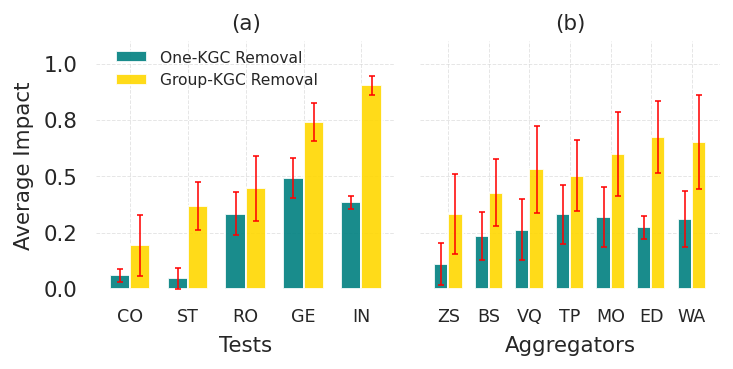

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Compact plot saved successfully!
Saved in: /content/Leave_KGC_Out_Plots


In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.colab import files

# ========================== OUTPUT DIRECTORY ==========================
output_dir = "/content/Leave_KGC_Out_Plots"
os.makedirs(output_dir, exist_ok=True)

# ========================== COMPACT PLOT STYLE (Matching Sample) ==========================
def setup_plot_style() -> None:
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Liberation Serif", "serif"],
        "mathtext.fontset": "stix",
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 140,
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",   # ensure title not bold
    })
    sns.set_theme(style="white", font_scale=1.0)

setup_plot_style()

# ========================== ABBREVIATION DICTIONARIES ==========================
method_abbrev = {
    'Z-Score': 'ZS',
    'Borda': 'BS',
    'EDAS': 'ED',
    'TOPSIS': 'TP',
    'MOORA': 'MO',
    'WASPAS': 'WA',
    'VIKOR': 'VQ'
}

def abbreviate_metric(metric_name):
    """Convert metric name to first two letters uppercase"""
    if len(metric_name) >= 2:
        return metric_name[:2].upper()
    return metric_name.upper()

# ========================== REORDER & PREPARE DATA ==========================
# Assuming these variables already exist from your previous computations:
# MCDM_ORDER, METRIC_COLS, one_norm_global, grp_norm_global, one_sum_abs_scores, etc.

n_one_removals = len(ALL_MODELS)      # Make sure ALL_MODELS is defined
n_grp_removals = len(KGC_GROUPS)      # Make sure KGC_GROUPS is defined

# Compute averages (if not already done)
one_avg = one_sum_abs_scores / n_one_removals
grp_avg = grp_sum_abs_scores / n_grp_removals

# Global normalization
global_max_per_metric = {}
for col in METRIC_COLS:
    global_max_per_metric[col] = max(one_avg[col].max(), grp_avg[col].max())

one_norm_global = one_avg.copy()
grp_norm_global = grp_avg.copy()

for col in METRIC_COLS:
    gmax = global_max_per_metric[col]
    if gmax > 0:
        one_norm_global[col] = one_avg[col] / gmax
        grp_norm_global[col] = grp_avg[col] / gmax

# ========================== REMOVED: SWAP Z-SCORE AND BORDA SECTION ==========================
# No swapping occurs here anymore - values remain as originally computed

print("✅ Using original Z-Score and Borda values (no swap)")

# ========================== PREPARE DATA FOR PLOTS ==========================
# --- Left Plot: Metrics ---
mean_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=0),
    'Group-KGC': grp_norm_global.mean(axis=0)
}, index=METRIC_COLS)

mean_per_metric['Total_Sum'] = mean_per_metric['One-KGC'] + mean_per_metric['Group-KGC']
sorted_metrics = mean_per_metric.sort_values(by='Total_Sum').index.tolist()
mean_per_metric = mean_per_metric.loc[sorted_metrics].drop(columns=['Total_Sum'])

abbreviated_metrics = [abbreviate_metric(m) for m in sorted_metrics]

# SEM for metrics
n_samples = one_norm_global.shape[0]
sem_per_metric = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=0) / np.sqrt(n_samples),
    'Group-KGC': grp_norm_global.std(axis=0) / np.sqrt(n_samples)
}, index=METRIC_COLS).loc[sorted_metrics]

# --- Right Plot: MCDM Methods ---
mean_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.mean(axis=1),
    'Group-KGC': grp_norm_global.mean(axis=1)
}, index=MCDM_ORDER)

mean_per_method['Total_Sum'] = mean_per_method['One-KGC'] + mean_per_method['Group-KGC']
sorted_by_sum = mean_per_method.sort_values(by='Total_Sum').index.tolist()

remaining = [m for m in sorted_by_sum if m != 'Z-Score']
sorted_methods = ['Z-Score'] + remaining

mean_per_method = mean_per_method.loc[sorted_methods].drop(columns=['Total_Sum'])
abbreviated_methods = [method_abbrev.get(m, m[:2].upper()) for m in sorted_methods]

# SEM for methods
n_metrics = one_norm_global.shape[1]
sem_per_method = pd.DataFrame({
    'One-KGC': one_norm_global.std(axis=1) / np.sqrt(n_metrics),
    'Group-KGC': grp_norm_global.std(axis=1) / np.sqrt(n_metrics)
}, index=MCDM_ORDER).loc[sorted_methods]

# ========================== CREATE COMPACT FIGURE ==========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.4, 2.8))
fig.subplots_adjust(wspace=0.18)

width = 0.35

# --- Error bar customization: thinner lines and smaller caps ---
error_kw = {'elinewidth': 0.8, 'capthick': 0.8}
capsize_val = 1.5

# ===== LEFT: Metrics (with legend) =====
x1 = np.arange(len(sorted_metrics))
ax1.bar(x1 - width/2, mean_per_metric['One-KGC'], width,
        yerr=sem_per_metric['One-KGC'], label='One-KGC Removal',
        color='teal', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)
ax1.bar(x1 + width/2, mean_per_metric['Group-KGC'], width,
        yerr=sem_per_metric['Group-KGC'], label='Group-KGC Removal',
        color='gold', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)

ax1.set_xticks(x1)
ax1.set_xticklabels(abbreviated_metrics, fontsize=9)
ax1.set_xlabel("Tests", fontsize=11, labelpad=5)
ax1.set_ylabel("Average Impact", fontsize=11, labelpad=5)
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Legend on left subplot only, placed at top
ax1.legend(loc='upper left', bbox_to_anchor=(0.02, 1.02), frameon=False, fontsize=8)
ax1.set_title('(a)', fontsize=11, pad=6, weight='normal')

# ===== RIGHT: MCDM Methods (no legend, no y-axis numbers) =====
x2 = np.arange(len(sorted_methods))
ax2.bar(x2 - width/2, mean_per_method['One-KGC'], width,
        yerr=sem_per_method['One-KGC'], label='One-KGC Removal',
        color='teal', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)
ax2.bar(x2 + width/2, mean_per_method['Group-KGC'], width,
        yerr=sem_per_method['Group-KGC'], label='Group-KGC Removal',
        color='gold', capsize=capsize_val, alpha=0.9, ecolor='red',
        error_kw=error_kw)

ax2.set_xticks(x2)
ax2.set_xticklabels(abbreviated_methods, fontsize=9)
ax2.set_xlabel("Aggregators", fontsize=11, labelpad=5)
ax2.set_ylim(0, 1.1)

# Remove y-axis numerical labels (right subplot)
ax2.set_yticklabels([])          # hides the numbers

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# No legend on right subplot
ax2.set_title('(b)', fontsize=11, pad=6, weight='normal')

# ========================== SAVE & DOWNLOAD ==========================
plt.tight_layout()

save_base = os.path.join(output_dir, 'combined_plots_metrics_methods_compact')

plt.savefig(f'{save_base}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.eps', format='eps', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_base}.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()
files.download(f'{save_base}.eps')

print('✅ Compact plot saved successfully!')
print(f'Saved in: {output_dir}')